In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


## Goal

#### The goal for this lab is to determine weather a resistor, light-bulb, and  LED (Light-Emitting Diode) follow ohms law.

## Procedure  

1. Construct the circuit:  
   - Connect a resistor in series with an ammeter and in parallel with a voltmeter.  
   - The voltmeter measures the voltage drop across the resistor.  
   - The ammeter measures the current supplied.  

2. Define the relationship:  
   - The general model for voltage and current is:  
     $$
     V = A \cdot I^B
     $$ 

3. Linearize the equation:  
   - Take the natural logarithm of both sides:  
     $$
     \ln(V) = \ln(A) + B \ln(I)
     $$  
   - This transforms the equation into a linear form:  
     - ln(V) vs. ln(I) should form a straight line.  
     - The slope of this line represents B.  

4. Perform linear regression:  
   - Fit a linear regression model to estimate \( A \) and \( B \).  
   - If \( B = 1 \), the relationship is ohmic (follows Ohm’s Law).  

5. Repeat for other components:  
   - Repeat the experiment using light bulbs and LEDs.  
   - Analyze whether these components also obey Ohm’s Law.  


# Ohmic relationship in Resistor

In [2]:
## Getting the measured data for the resistor 

resistor_data = pd.read_csv("data/resistor.csv")
resistor_data.head()

,Voltage (V),dVoltage (V),Current (μA),dCurrent (μA)
0,1.245,NaN,123.6,NaN
1,2.143,NaN,212.1,NaN
2,3.005,NaN,296.8,NaN
3,3.860,NaN,384.0,NaN
4,4.850,NaN,483.0,NaN


In [3]:
# Converting the micro ampere to ampere
resistor_data["Current (μA)"] = resistor_data['Current (μA)'] * 1e-6

#### According to the manual  

The uncertainties for voltage and current measurements are given by:  

$$ 
\text{Uncertainty of Voltage} = 0.8\% \times \text{Measured Voltage} + 1 \text{ digit} 
$$  

$$ 
\text{Uncertainty of Current} = 0.8\% \times \text{Measured Current} + 1 \text{ digit} 
$$  

These uncertainties account for both the proportional error and the least significant digit error in the measurements.


In [4]:
def uncertainity_function(val, digit):
    
    return (0.008 * val) + digit 

In [17]:
# calculate the uncertainities
resistor_data["dCurrent (μA)"] = resistor_data["Current (μA)"].apply(lambda val: uncertainity_function(val, 0.1 * 1e-6))          # make sure that the digit is converted from micro ampere to ampere
resistor_data["dVoltage (V)"] = resistor_data["Voltage (V)"].apply(lambda val: uncertainity_function(val, 0.001))

resistor_data

,Voltage (V),dVoltage (V),Current (μA),dCurrent (μA)
0,1.245,0.010960,0.000124,0.000001
1,2.143,0.018144,0.000212,0.000002
2,3.005,0.025040,0.000297,0.000002
3,3.860,0.031880,0.000384,0.000003
4,4.850,0.039800,0.000483,0.000004
5,5.880,0.048040,0.000584,0.000005
6,6.860,0.055880,0.000682,0.000006
7,8.080,0.065640,0.000802,0.000007
8,8.920,0.072360,0.000885,0.000007
9,10.120,0.081960,0.001006,0.000008


## Dominant Source of Uncertainity 

#### TODO:

#### Lets visualize the data to notice any relationship between the voltage drop accross a resistor and the current

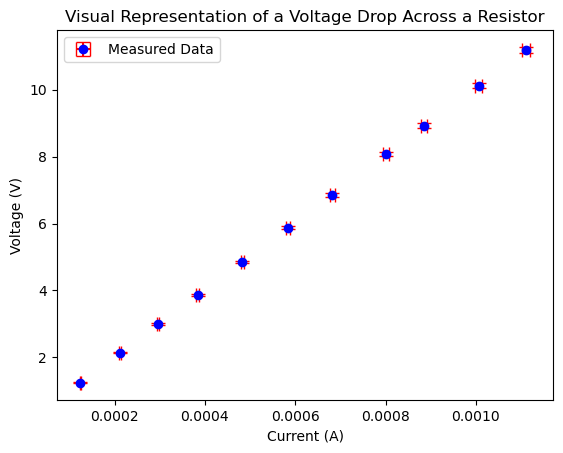

In [21]:
# Visualizing the relationship

x = resistor_data["Current (μA)"]
y = resistor_data["Voltage (V)"]
x_err = resistor_data["dCurrent (μA)"]
y_err = resistor_data["dVoltage (V)"]


# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Visual Representation of a Voltage Drop Across a Resistor")
plt.legend()
plt.show()



#### Eyeballing the graph, we can see that the relationship appears to be linear. However, eyeballing alone is not scientific, so let's attempt to prove that the relationship is ohmic using a scientific approach.


#### The general equation model for the relationship between voltage and current is:

$$
V = A \cdot I^B
$$


#### However, estimating the parameter \( B \) might be challenging because this model is exponential. To simplify the process, we will linearize the relationship by taking the natural logarithm on both sides.

Taking the natural logarithm of the general model:

$$
V = A \cdot I^B
$$

Applying \( \ln \) to both sides:

$$
\ln(V) = \ln(A \cdot I^B)
$$

Using logarithm properties:

$$
\ln(V) = \ln(A) + B \ln(I)
$$

This transformation results in a linear equation of the form:

$$
Y = mX + C
$$

where:

- $ Y = \ln(V) $ (dependent variable)
- $ X = \ln(I) $ (independent variable)
- $ m = B $ (slope)
- $ C = \ln(A) $ (intercept)

This linearized form allows us to estimate \( B \) more easily using linear regression.


In [25]:
#### Taking the natural logarithm of the measured data

resistor_data["ln(V)"] = np.log(resistor_data["Voltage (V)"])
resistor_data["ln(I)"] = np.log(resistor_data["Current (μA)"])

### Error Propagation for the Natural Logarithm  

For a measured value $ X $ with uncertainty $ \Delta X $, the propagated error when taking the natural logarithm is:

$$
\Delta \ln(X) = \frac{\Delta X}{X}
$$




In [28]:
resistor_data["d_ln(V)"] = resistor_data["dVoltage (V)"] / resistor_data["Voltage (V)"]
resistor_data["d_ln(I)"] = resistor_data["dCurrent (μA)"] / resistor_data["Current (μA)"]

In [31]:
resistor_data

,Voltage (V),dVoltage (V),Current (μA),dCurrent (μA),ln(V),ln(I),d_ln(V),d_ln(I)
0,1.245,0.010960,0.000124,0.000001,0.219136,-8.998460,0.008803,0.008809
1,2.143,0.018144,0.000212,0.000002,0.762207,-8.458453,0.008467,0.008471
2,3.005,0.025040,0.000297,0.000002,1.100278,-8.122452,0.008333,0.008337
3,3.860,0.031880,0.000384,0.000003,1.350667,-7.864868,0.008259,0.008260
4,4.850,0.039800,0.000483,0.000004,1.578979,-7.635494,0.008206,0.008207
5,5.880,0.048040,0.000584,0.000005,1.771557,-7.445610,0.008170,0.008171
6,6.860,0.055880,0.000682,0.000006,1.925707,-7.290481,0.008146,0.008147
7,8.080,0.065640,0.000802,0.000007,2.089392,-7.128402,0.008124,0.008125
8,8.920,0.072360,0.000885,0.000007,2.188296,-7.029923,0.008112,0.008113
9,10.120,0.081960,0.001006,0.000008,2.314514,-6.901773,0.008099,0.008099


In [33]:
#### Using curve fit to estimate the parameters A and B

def linear_model(x, B, A):
    return B * x + A

x = resistor_data["ln(I)"] 
y = resistor_data["ln(V)"]
y_err = resistor_data["d_ln(V)"] 
x_err = resistor_data["d_ln(I)"]

# getting the best fit line
parameters, errors = curve_fit( linear_model, x, y, sigma = y_err, absolute_sigma=True )

slope = parameters[0]
intercept = parameters[1]
print(f"{slope}, {intercept}")
errors

0.9986398320399452, 9.207227440365793


array([[1.47722606e-05, 1.11933222e-04],
       [1.11933222e-04, 8.54331363e-04]])

### Estimated Fit Parameters and Covariance Matrix  

The estimated parameters for the fit are:  

$$
B = 1.0000 \pm 0.0014
$$  

$$
A = -9.2072 \pm 0.0009
$$  




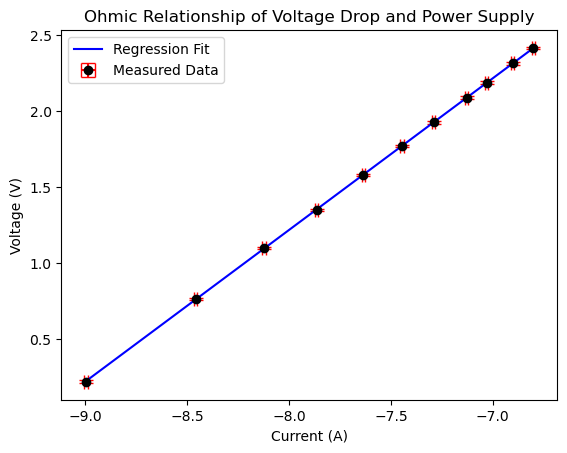

In [35]:
#### Visualizing the regression fit

# Plot with error bars
plt.errorbar(
    x, y, 
    yerr=y_err, xerr=x_err,
    fmt="o", capsize=5, markersize=6, 
    color="black", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Ohmic Relationship of Voltage Drop and Power Supply")


# plotting the regression fit
line_space = np.linspace(min(x), max(x), 1000)
y = linear_model(line_space, slope, intercept)
plt.plot(line_space, y, label="Regression Fit", color='blue')

plt.legend(); 
plt.show()

#### Estimating Resistance from Parameter A  

We have estimated the parameter \( B \) in the general model:  

$$
V = A \cdot I^B
$$  

to be **1**, confirming the relationship is **linear**. Additionally, we have estimated log(A) to be **-9.207** with an uncertainty of **0.0009**.  

To find \( A \), we exponentiate both sides:  

$$
A = e^{-9.207}
$$  

Evaluating this:  

$$
A \approx (1.002 \pm 0.002) \times 10^{-4}
$$  

### **Error Propagation for \( A \)**  
Using the general rule for error propagation of exponentials:  

$$
\Delta A = A \cdot \Delta(\log A)
$$  

Substituting values:  

$$
\Delta A = (1.002 \times 10^{-4}) \times (0.0009)
$$  

$$
\Delta A \approx 9.02 \times 10^{-8}
$$  

### **Estimating Resistance and its Uncertainty**  

Since resistance is given by the reciprocal of \( A \):  

$$
R = \frac{1}{A}
$$  

Using the error propagation formula for reciprocals:  

$$
\frac{\Delta R}{R} = \frac{\Delta A}{A}
$$  

Solving for \( \Delta R \):  

$$
\Delta R = R \cdot \frac{\Delta A}{A}
$$  

Substituting values:  

$$
\Delta R = (9.98 \times 10^4) \times \frac{9.02 \times 10^{-8}}{1.002 \times 10^{-4}}
$$  

$$
\Delta R \approx 9.00 \times 10^{-1} \, \Omega
$$  

### **Final Result**  
Thus, the estimated resistance with its uncertainty is:  

$$
R = (9.980 \pm 0.009) \times 10^4 \, \Omega
$$  


## Comparision to the Accepted Value  

### Linearity of the Relationship  

We can conclude that the relationship is **linear** since we have estimated the exponent \( B \) to be **1**, within experimental uncertainty.  

### Resistance of the Resistor
According to Ohm’s Law, the relationship between voltage, current, and resistance is given by: 

$$
R = \frac{V}{R}
$$  

The expected **average resistance** of the resistor is computed as:  

$$
R_{\text{avg}} = \frac{1}{N} \sum_{i=1}^{N} \frac{V_i}{I_i}
$$  

where \( N \) is the total number of data points, and each individual resistance is calculated as **voltage divided by current**.

In [39]:
# Calculating the average resistance

resistance = resistor_data["Voltage (V)"] / resistor_data["Current (μA)"]

# print the resistance arary
print(np.array(resistance))
print('\n')

# printing the avg resistance
print(np.mean(resistance))

[10072.81553398 10103.72465818 10124.66307278 10052.08333333
 10041.40786749 10068.49315068 10058.65102639 10074.81296758
 10079.0960452  10059.64214712 10062.94964029]


10072.576313002444


$$
Avg \space resistance = 1.007 \times 10^{4} \space \Omega
$$

### Comparison of estimated resistance to average resistance from ohms law

Although the average resistance does not fall within the uncertainty range of our estimate, it is very close. The slight underestimation may be attributed to errors in our measurements, such as instrumental inaccuracies, contact resistance, or small variations in current and voltage readings.


# Ohmic Relationship in a Light Bulb

In [45]:
# Getting the meausured data from the light bulb

bulb_data = pd.read_csv("data/light_bulb.csv")
bulb_data.head()

,Voltage (V),dVoltage (V),Current (mA),dCurrent (mA)
0,0.842,NaN,97.2,NaN
1,1.440,NaN,129.5,NaN
2,2.273,NaN,166.0,NaN
3,3.282,NaN,203.5,NaN
4,4.090,NaN,229.6,NaN


In [47]:
# converting the mili Ampere to Ampere

bulb_data["Current (mA)"] *= 1e-3

#### Calculating the uncertainities

In [50]:
bulb_data["dCurrent (mA)"] = bulb_data["Current (mA)"].apply(lambda val: uncertainity_function(val, 0.1 * 1e-3 ))
bulb_data["dVoltage (V)"] = bulb_data["Voltage (V)"].apply(lambda val: uncertainity_function(val, 0.001))

bulb_data


,Voltage (V),dVoltage (V),Current (mA),dCurrent (mA)
0,0.842,0.007736,0.0972,0.000878
1,1.440,0.012520,0.1295,0.001136
2,2.273,0.019184,0.1660,0.001428
3,3.282,0.027256,0.2035,0.001728
4,4.090,0.033720,0.2296,0.001937
5,5.340,0.043720,0.2665,0.002232
6,6.520,0.053160,0.2975,0.002480
7,8.020,0.065160,0.3335,0.002768
8,9.260,0.075080,0.3608,0.002986
9,10.850,0.087800,0.3940,0.003252


In [52]:
bulb_data["dCurrent (mA)"] = bulb_data["Current (mA)"].apply(lambda val: uncertainity_function(val, 0.1 * 1e-3 ))
bulb_data["dVoltage (V)"] = bulb_data["Voltage (V)"].apply(lambda val: uncertainity_function(val, 0.001))

bulb_data


,Voltage (V),dVoltage (V),Current (mA),dCurrent (mA)
0,0.842,0.007736,0.0972,0.000878
1,1.440,0.012520,0.1295,0.001136
2,2.273,0.019184,0.1660,0.001428
3,3.282,0.027256,0.2035,0.001728
4,4.090,0.033720,0.2296,0.001937
5,5.340,0.043720,0.2665,0.002232
6,6.520,0.053160,0.2975,0.002480
7,8.020,0.065160,0.3335,0.002768
8,9.260,0.075080,0.3608,0.002986
9,10.850,0.087800,0.3940,0.003252


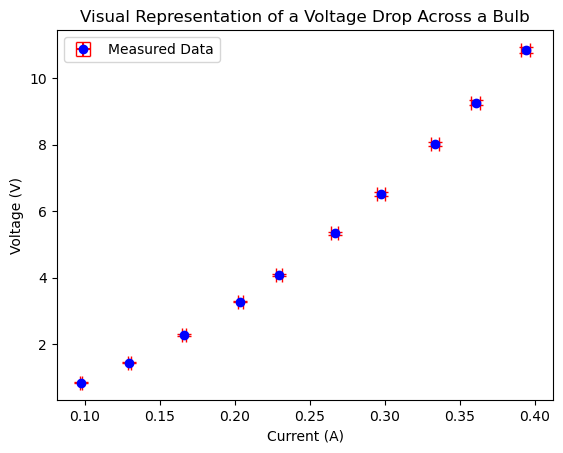

In [54]:
# Visualizing the relationship

x = bulb_data["Current (mA)"]
y = bulb_data["Voltage (V)"]
x_err = bulb_data["dCurrent (mA)"]
y_err = bulb_data["dVoltage (V)"]

# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Visual Representation of a Voltage Drop Across a Bulb")
plt.legend()
plt.show()


#### Taking the natrual log on both sides to linearize the data

In [57]:
bulb_data["ln(V)"] = np.log(bulb_data["Voltage (V)"])
bulb_data["ln(I)"] = np.log(bulb_data["Current (mA)"])

#### Propagating the uncertainity for the natrual logarith. Propagation formula is stated in the resistance section

In [184]:
bulb_data["d_ln(V)"] = bulb_data["dVoltage (V)"] / bulb_data["Voltage (V)"]
bulb_data["d_ln(I)"] = bulb_data["dCurrent (mA)"] / bulb_data["Current (mA)"]


#### Plotting the linear regression fit for the linearized data

In [187]:
x = bulb_data["ln(I)"] 
y = bulb_data["ln(V)"]
y_err = bulb_data["d_ln(V)"] 
x_err = bulb_data["d_ln(I)"]

# Getting the best-fit line
parameters, errors = curve_fit(linear_model, x, y, sigma=y_err, absolute_sigma=True)

slope = parameters[0]
intercept = parameters[1]
print(f"{slope}, {intercept}")
errors


1.8205852903537176, 4.083137549259459


array([[3.88557969e-05, 5.64073143e-05],
       [5.64073143e-05, 8.88354126e-05]])

### Estimating Resistance from the Intercept  

The estimated parameters for the fit are:  

$$
B = 1.8205 \pm 0.0004
$$  

$$
\ln(A) = 4.0313 \pm 0.0009
$$  

To estimate the resistance \( R \), we exponentiate the intercept:  

$$
A = e^{4.0313}
$$

Evaluating:  

$$
A \approx 56.24
$$

Since resistance is given by the reciprocal of \( A \):  

$$
R = \frac{1}{A} = \frac{1}{56.24}
$$

Evaluating:  

$$
R \approx 0.0178 \, \Omega
$$  

### **Propagation of Uncertainty**  

Using error propagation for exponentials:  

$$
\Delta A = A \cdot \Delta (\ln A)
$$

Substituting values:  

$$
\Delta A = (56.24) \times (0.0009) \approx 0.051
$$  

For reciprocals, the uncertainty propagates as:  

$$
\Delta R = R \cdot \frac{\Delta A}{A}
$$

Substituting values:  

$$
\Delta R = (0.0178) \times \frac{0.051}{56.24}
$$  

$$
\Delta R \approx 1.6 \times 10^{-5} \, \Omega
$$  

### **Estimated Resistance**  

$$
R = (1.78 \pm 0.016) \times 10^{-2} \, \Omega
$$  

Thus, the estimated resistance from the intercept is $$ (1.78 \pm 0.016) \times 10^{-2} \, \Omega $$.


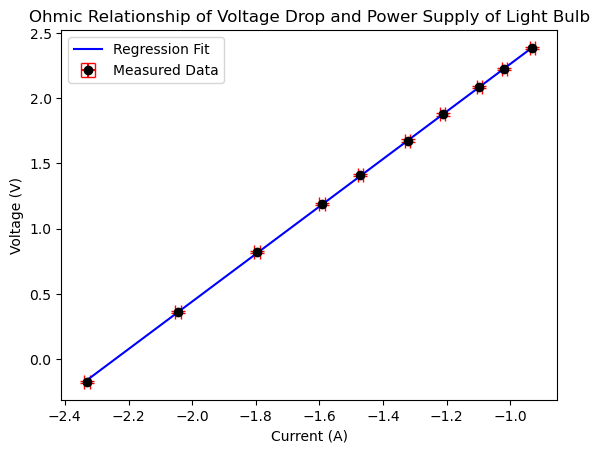

In [189]:
#### Visualizing the regression fit

# Plot with error bars
plt.errorbar(
    x, y, 
    yerr=y_err, xerr=x_err,
    fmt="o", capsize=5, markersize=6, 
    color="black", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Ohmic Relationship of Voltage Drop and Power Supply of Light Bulb")


# plotting the regression fit
line_space = np.linspace(min(x), max(x), 1000)
y = linear_model(line_space, slope, intercept)
plt.plot(line_space, y, label="Regression Fit", color='blue')

plt.legend(); 
plt.show()

In [192]:
# Calculating the average resistance

resistance = bulb_data["Voltage (V)"] / bulb_data["Current (mA)"]

# Print the resistance array
print(np.array(resistance))
print('\n')

# Printing the average resistance
print(np.mean(resistance))


[ 8.66255144 11.11969112 13.69277108 16.12776413 17.81358885 20.03752345
 21.91596639 24.04797601 25.66518847 27.53807107]


18.66210920090586


### Comparison to Ohm’s Law  

**Calculated resistance:**  
$$
R_{\text{calc}} = (1.78 \pm 0.016) \times 10^{-2} \, \Omega
$$  

**Expected resistance:**  
$$
R_{\text{Ohm}} = 18.6621 \, \Omega
$$  




The large error suggests non-ohmic behavior maydue to temperature effects and variable resistance like the one from the wire and the fillament. This non ohmic relationship might also be due to our quality of data where our Ammeter or voltmeter might not be connnected or working well enough.



# Ohmic relattionship in light emeting diods

#### Getting the measured data

In [197]:
led_data = pd.read_csv("data/led_light.csv")
led_data


,Voltage (V),dVoltage (V),Current (μA),dCurrent (μA)
0,-11.500,NaN,-1.00,NaN
1,-9.500,NaN,-0.90,NaN
2,-8.450,NaN,-0.80,NaN
3,-7.270,NaN,-0.70,NaN
4,-6.100,NaN,-0.50,NaN
5,-5.170,NaN,-0.40,NaN
6,-4.130,NaN,-0.30,NaN
7,-3.382,NaN,-0.20,NaN
8,-2.243,NaN,-0.10,NaN
9,-1.253,NaN,0.01,NaN


In [198]:
# converting the micro ampers to ampere

led_data["Current (μA)"] *= 1e-6

#### The first 10 of the data is a reverse bias circuit and the rest is forward bias 

In [232]:
reverse_bias = led_data.iloc[:10, :].copy(deep=True)
forward_bias = led_data.iloc[12:,:].copy(deep=True)      # 10 AND 11 ARE ANOMALYS SO WE ARE EXCLUDING THEM

reverse_bias.head()

,Voltage (V),dVoltage (V),Current (μA),dCurrent (μA)
0,-11.50,NaN,-1.000000e-06,NaN
1,-9.50,NaN,-9.000000e-07,NaN
2,-8.45,NaN,-8.000000e-07,NaN
3,-7.27,NaN,-7.000000e-07,NaN
4,-6.10,NaN,-5.000000e-07,NaN


#### populating the voltage and current uncertaintiy for the reverse bias

In [235]:
reverse_bias["dVoltage (V)"] = reverse_bias["Voltage (V)"].apply(lambda val: uncertainity_function(val, 0.01))
reverse_bias["dCurrent (μA)"] = reverse_bias["Current (μA)"].apply(lambda val: uncertainity_function(val, 0.1 * 1e-6))

reverse_bias

,Voltage (V),dVoltage (V),Current (μA),dCurrent (μA)
0,-11.500,-0.082000,-1.000000e-06,9.200000e-08
1,-9.500,-0.066000,-9.000000e-07,9.280000e-08
2,-8.450,-0.057600,-8.000000e-07,9.360000e-08
3,-7.270,-0.048160,-7.000000e-07,9.440000e-08
4,-6.100,-0.038800,-5.000000e-07,9.600000e-08
5,-5.170,-0.031360,-4.000000e-07,9.680000e-08
6,-4.130,-0.023040,-3.000000e-07,9.760000e-08
7,-3.382,-0.017056,-2.000000e-07,9.840000e-08
8,-2.243,-0.007944,-1.000000e-07,9.920000e-08
9,-1.253,-0.000024,1.000000e-08,1.000800e-07


In [237]:
forward_bias["dVoltage (V)"] = forward_bias["Voltage (V)"].apply(lambda val: uncertainity_function(val, 0.01))
forward_bias["dCurrent (μA)"] = forward_bias["Current (μA)"].apply(lambda val: uncertainity_function(val, 0.1 * 1e-6))

forward_bias

,Voltage (V),dVoltage (V),Current (μA),dCurrent (μA)
12,2.404,0.029232,0.000005,1.432000e-07
13,2.462,0.029696,0.000029,3.360000e-07
14,2.491,0.029928,0.000071,6.656000e-07
15,2.525,0.030200,0.000163,1.400800e-06
16,2.559,0.030472,0.000330,2.740000e-06
17,2.612,0.030896,0.000800,6.500000e-06
18,2.644,0.031152,0.001150,9.300000e-06
19,2.709,0.031672,0.001990,1.602000e-05
20,2.791,0.032328,0.003260,2.618000e-05
21,2.863,0.032904,0.004380,3.514000e-05


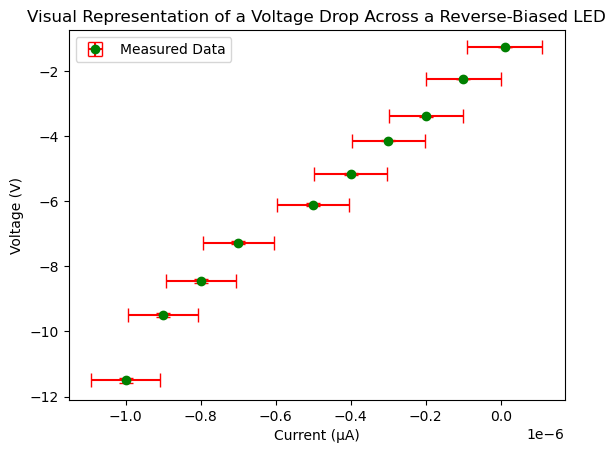

In [239]:
# Visualizing the relationship for the reverse bias circuit
x = reverse_bias["Current (μA)"]
y = reverse_bias["Voltage (V)"]
x_err = reverse_bias["dCurrent (μA)"]
y_err = np.abs(reverse_bias["dVoltage (V)"])

# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err,
    fmt="o", capsize=5, markersize=6, 
    color="green", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Current (μA)")
plt.ylabel("Voltage (V)")
plt.title("Visual Representation of a Voltage Drop Across a Reverse-Biased LED")
plt.legend()
plt.show()


#### Taking the natrual log on both sides to linearize the data

In [242]:
reverse_bias["ln(V)"] = np.log(np.abs(reverse_bias["Voltage (V)"]))
reverse_bias["ln(I)"] = np.log(np.abs(reverse_bias["Current (μA)"])) 

reverse_bias

,Voltage (V),dVoltage (V),Current (μA),dCurrent (μA),ln(V),ln(I)
0,-11.500,-0.082000,-1.000000e-06,9.200000e-08,2.442347,-13.815511
1,-9.500,-0.066000,-9.000000e-07,9.280000e-08,2.251292,-13.920871
2,-8.450,-0.057600,-8.000000e-07,9.360000e-08,2.134166,-14.038654
3,-7.270,-0.048160,-7.000000e-07,9.440000e-08,1.983756,-14.172186
4,-6.100,-0.038800,-5.000000e-07,9.600000e-08,1.808289,-14.508658
5,-5.170,-0.031360,-4.000000e-07,9.680000e-08,1.642873,-14.731801
6,-4.130,-0.023040,-3.000000e-07,9.760000e-08,1.418277,-15.019483
7,-3.382,-0.017056,-2.000000e-07,9.840000e-08,1.218467,-15.424948
8,-2.243,-0.007944,-1.000000e-07,9.920000e-08,0.807814,-16.118096
9,-1.253,-0.000024,1.000000e-08,1.000800e-07,0.225541,-18.420681


In [244]:
# getting the uncertainity for the reverse_bias

reverse_bias["d_ln(V)"] = reverse_bias["dVoltage (V)"] / reverse_bias["Voltage (V)"]
reverse_bias["d_ln(I)"] = reverse_bias["dCurrent (μA)"] / reverse_bias["Current (μA)"]


In [246]:
x = reverse_bias["ln(I)"] 
y = reverse_bias["ln(V)"]
y_err = reverse_bias["d_ln(V)"] 
x_err = reverse_bias["d_ln(I)"]

# Getting the best-fit line
parameters, errors = curve_fit(linear_model, x, y, sigma=y_err, absolute_sigma=True)

slope = parameters[0]
intercept = parameters[1]
print(f"{slope}, {intercept}")
errors


0.39060358108183124, 7.420718804913338


array([[2.81199448e-07, 5.17978388e-06],
       [5.17978388e-06, 9.54136446e-05]])

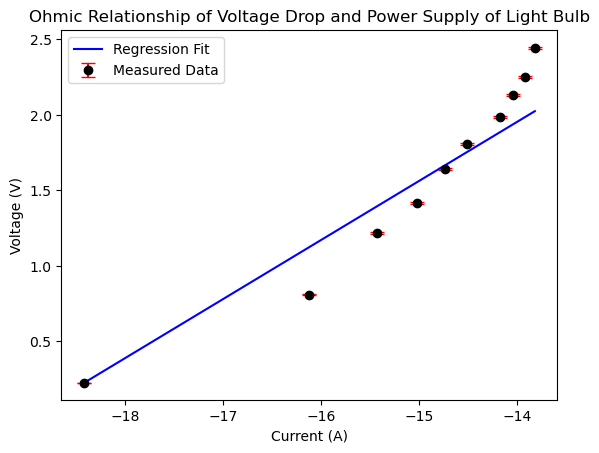

In [248]:
#### Visualizing the regression fit

# Plot with error bars
plt.errorbar(
    x, y, 
    yerr=y_err,
    fmt="o", capsize=5, markersize=6, 
    color="black", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Ohmic Relationship of Voltage Drop and Power Supply of Light Bulb")


# plotting the regression fit
line_space = np.linspace(min(x), max(x), 1000)
y = linear_model(line_space, slope, intercept)
plt.plot(line_space, y, label="Regression Fit", color='blue')

plt.legend(); 
plt.show()

#### Now we are going to visualize the relationship on the forward_bias circuit

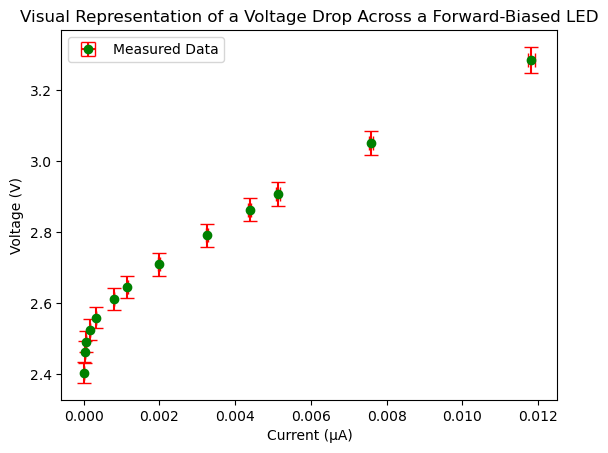

In [251]:

x = forward_bias["Current (μA)"]
y = forward_bias["Voltage (V)"]
x_err = forward_bias["dCurrent (μA)"]
y_err = np.abs(forward_bias["dVoltage (V)"])

# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err,
    fmt="o", capsize=5, markersize=6, 
    color="green", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Current (μA)")
plt.ylabel("Voltage (V)")
plt.title("Visual Representation of a Voltage Drop Across a Forward-Biased LED")
plt.legend()
plt.show()


#### We are now going to linearize the data by taking the natural logarithm 

In [268]:
forward_bias["ln(V)"] = np.log(forward_bias["Voltage (V)"])
forward_bias["ln(I)"] = np.log(forward_bias["Current (μA)"])

forward_bias.head()


,Voltage (V),dVoltage (V),Current (μA),dCurrent (μA),ln(V),ln(I),d_ln(V),d_ln(I)
12,2.404,0.029232,0.000005,1.432000e-07,0.877134,-12.129112,0.012160,0.026519
13,2.462,0.029696,0.000029,3.360000e-07,0.900974,-10.431120,0.012062,0.011390
14,2.491,0.029928,0.000071,6.656000e-07,0.912684,-9.557065,0.012014,0.009414
15,2.525,0.030200,0.000163,1.400800e-06,0.926241,-8.724217,0.011960,0.008615
16,2.559,0.030472,0.000330,2.740000e-06,0.939617,-8.016418,0.011908,0.008303


In [270]:
# Getting the uncertainty for the forward_bias

forward_bias["d_ln(V)"] = forward_bias["dVoltage (V)"] / forward_bias["Voltage (V)"]
forward_bias["d_ln(I)"] = forward_bias["dCurrent (μA)"] / forward_bias["Current (μA)"]


In [272]:
x = forward_bias["ln(I)"] 
y = forward_bias["ln(V)"]
y_err = forward_bias["d_ln(V)"] 
x_err = forward_bias["d_ln(I)"]

# Getting the best-fit line
parameters, errors = curve_fit(linear_model, x, y, sigma=y_err, absolute_sigma=True)

slope = parameters[0]
intercept = parameters[1]
print(f"{slope}, {intercept}")
errors


0.035871409248660835, 1.257370036033572


array([[2.09648737e-06, 1.50398122e-05],
       [1.50398122e-05, 1.18418568e-04]])

### Final Results  

From the curve fitting, we obtained the following estimates:  

- **Slope ( B )**:  

$$
B = (3.587 \pm 0.00145) \times 10^{-2}
$$  

- **Intercept ln(A)**:  

$$
\ln(A) = 1.257 \pm 0.011
$$  

### Uncertainty Calculation  

The uncertainties for the parameters are derived from the **square roots of the diagonal elements** of the covariance matrix:  

$$
\Delta B = \sqrt{2.09648737 \times 10^{-6}} = 0.00145
$$  

$$
\Delta \ln(A) = \sqrt{1.18418568 \times 10^{-4}} = 0.011
$$  

### Final Answer (Rounded to Correct Significant Figures)  

$$
B = (3.59 \pm 0.01) \times 10^{-2}
$$  

$$
\ln(A) = 1.257 \pm 0.011
$$  


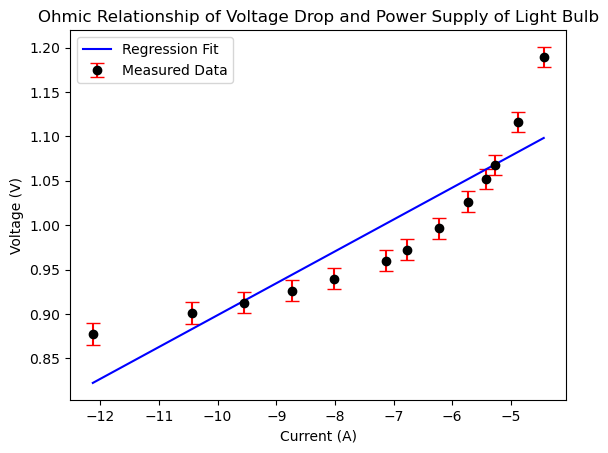

In [274]:
#### Visualizing the regression fit

# Plot with error bars
plt.errorbar(
    x, y, 
    yerr=y_err,
    fmt="o", capsize=5, markersize=6, 
    color="black", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Current (A)")
plt.ylabel("Voltage (V)")
plt.title("Ohmic Relationship of Voltage Drop and Power Supply of Light Bulb")


# plotting the regression fit
line_space = np.linspace(min(x), max(x), 1000)
y = linear_model(line_space, slope, intercept)
plt.plot(line_space, y, label="Regression Fit", color='blue')

plt.legend(); 
plt.show()

# Non-Ohmic Behavior of the Light-Emitting Diode  

The light-emitting diode does not appear to follow an ohmic relationship because the slope of the linearized data is **1**. If the slope is inaccurate, then the resistance estimate becomes irrelevant since the relationship itself does not conform to Ohm’s Law.  


TION_HERE]).
a (this website)



## Comparison to the Accepted Value  

According to [this website](https://en.wikipedia.org/wiki/Diode_modelling), diodes follow an exponential voltage-current  relationship rather than an ohmic one. Unlike resistors, which obey Ohm’s Law and have a linear V-I curve, diodes exhibit a threshold voltage where almost no current flows, followed by a sharp increase in current once the applied voltage exceeds this threshold. This aligns with our experimental results, where the LED did not exhibit a constant resistance.

This behavior is explained by semiconductor physics and the Shockley diode equation, which describes the current through a p-n junction:

$$
I = I_0 \left(e^{qV / kT} - 1\right)
$$

where \( I_0 \) is the reverse saturation current, \( q \) is the charge of an electron, \( k \) is Boltzmann’s constant, and \( T \) is the absolute temperature. This equation shows that small increases in voltage lead to exponential increases in current, explaining why the LED’s resistance is not constant.

Additionally, the deviation from Ohm’s Law is expected due to the charge carrier dynamics in the LED. Unlike a metallic conductor where electrons flow freely, an LED operates through electron-hole recombination at the p-n junction, which introduces nonlinearities in its electrical response. The resistance is also temperature-dependent since increased current flow leads to self-heating, which affects charge carrier mobility and further modifies the diode's electrical behavior.





## Connection to Physics
 In this lab, we analyzed the voltage-current  relationships of a resistor, a light bulb, and a light-emitting diode  to determine whether they follow Ohm’s Law. Our results showed that the resistor exhibited a linear V-I relationship, confirming that it is an ohmic component with a constant resistance. The light bulb, however, displayed **non-ohmic behavior**, as its resistance increased with current, likely due to the filament heating up and altering its electrical properties. The LED also deviated from Ohm’s Law, showing an exponential increase in current after reaching a threshold voltage. This aligns with semiconductor physics, where charge carriers move across a p-n junction rather than through a uniform conductor. Additionally, we observed that the LED’s resistance is affected by temperature, as increased current led to self-heating, further modifying its electrical behavior. 



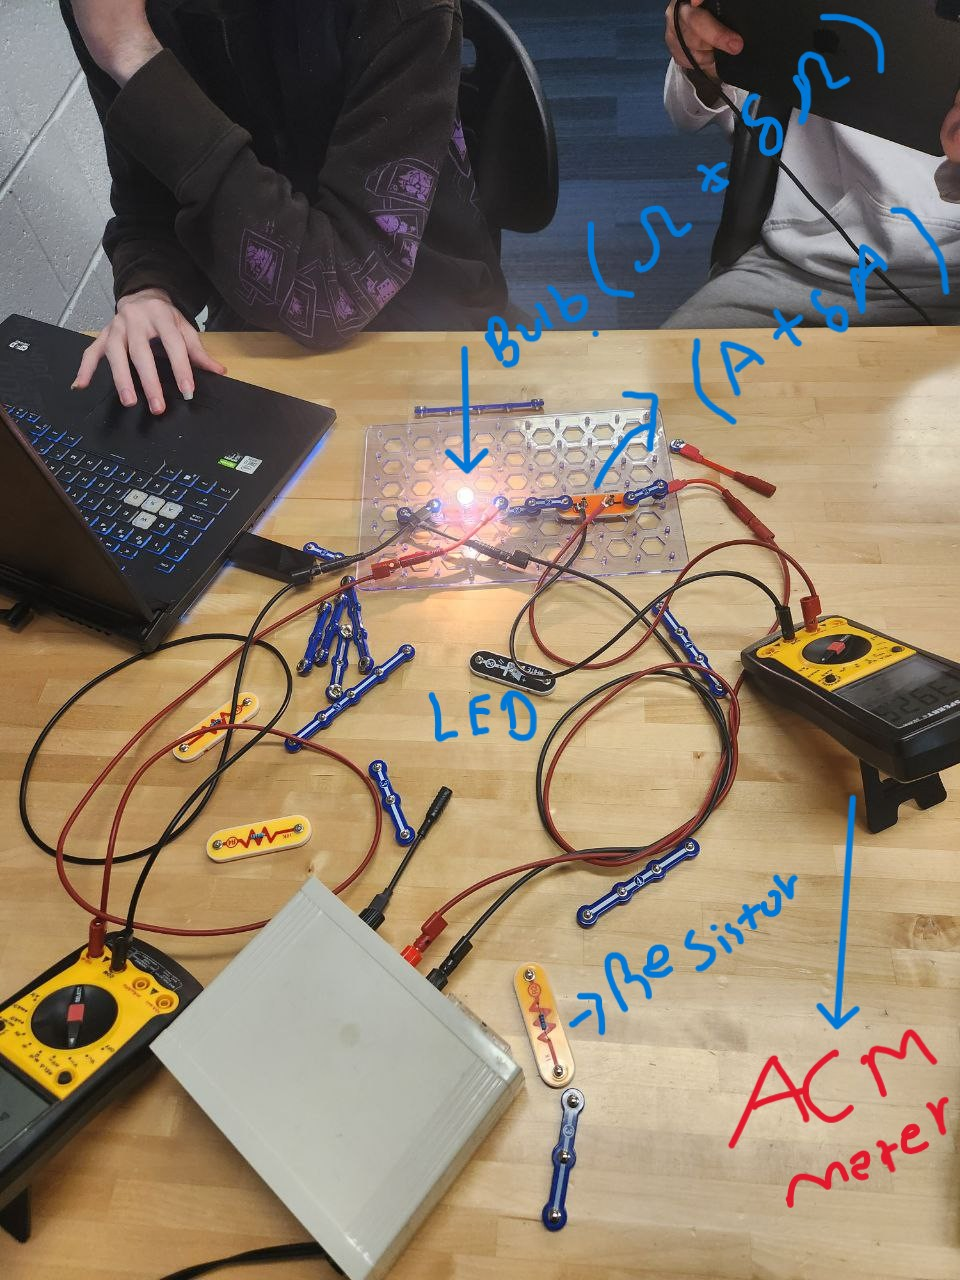